In [1]:
from src.data import load_data, split_by_year

data = load_data()
train, _, _ = split_by_year(data)

In [2]:
from src.config import RATIOS
from src.features import add_ratios

In [3]:
tr = add_ratios(train)
y = tr['default']

print(f"{len(tr):,} rows, {int(y.sum())} defaults, base rate {y.mean():.3%}")
tr[RATIOS].describe().T

55,927 rows, 403 defaults, base rate 0.721%


,count,mean,std,min,25%,50%,75%,max
tl_ta,55927.0,1.662128,41.962225,0.000041,0.289204,0.494001,0.698420,6324.000000
ltd_ta,55927.0,0.212067,1.637477,0.000000,0.000000,0.088466,0.275703,308.800000
mve_tl,55927.0,10.020059,126.710294,0.000002,0.835374,2.207505,6.172436,18795.900000
neg_eq,55927.0,0.090886,0.287450,0.000000,0.000000,0.000000,0.000000,1.000000
ni_ta,55927.0,-0.527259,12.082177,-1515.000000,-0.133998,0.017794,0.067743,244.833333
ebit_ta,55927.0,-0.342359,8.469111,-1241.000000,-0.081773,0.048255,0.107023,35.916667
gp_sales,55927.0,-3.868194,161.174982,-29325.700000,0.200312,0.346121,0.530276,358.210526
ca_cl,55927.0,3.697756,105.088969,-0.030374,1.172361,1.907303,3.210115,24108.000000
wc_ta,55927.0,-0.772346,40.336162,-6323.000000,0.040371,0.216920,0.429841,0.996997
quick,55927.0,3.189262,105.086383,-0.030374,0.830368,1.386782,2.542084,24108.000000


Here we can see that we have no missing values or errors in the ratios.

I will plot some graphs to visualise the data better

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import pandas as pd

In [5]:
corr = tr[RATIOS].corr(method='spearman')

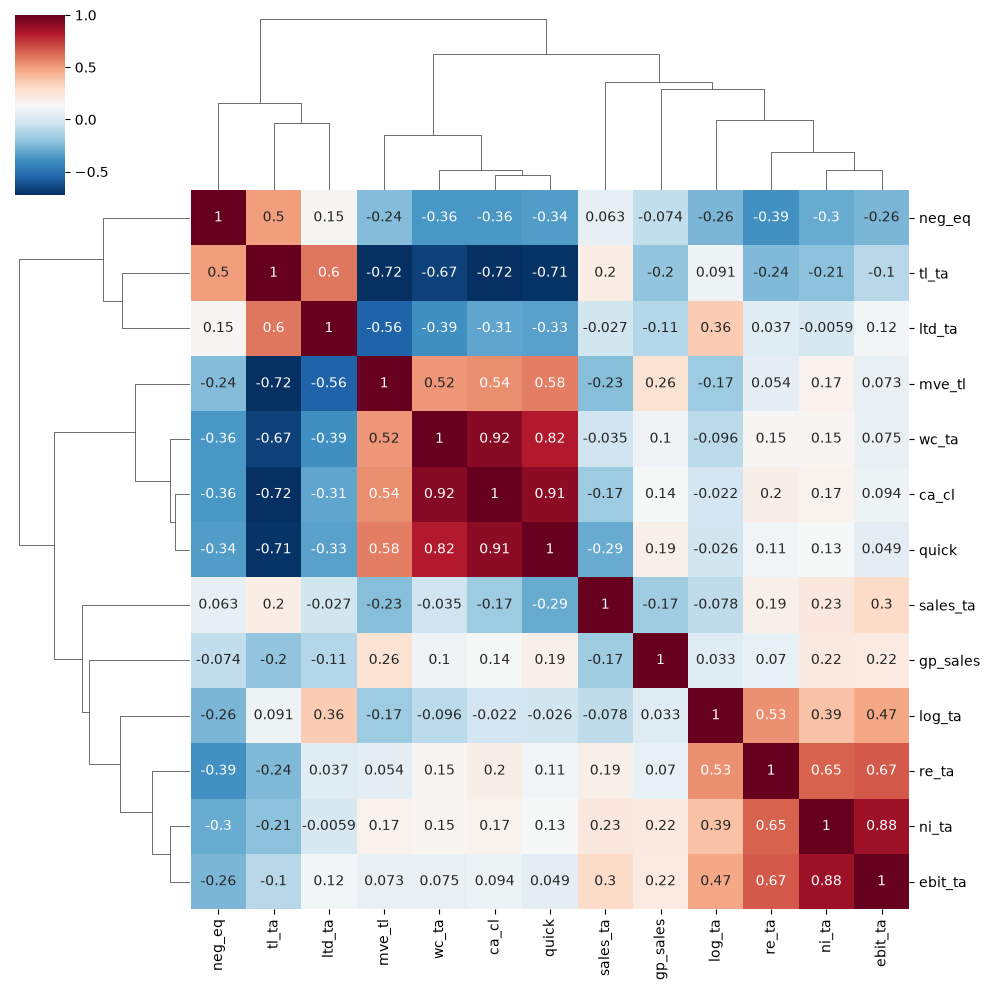

In [6]:
sns.clustermap(corr, cmap = 'RdBu_r', annot = True)

In [7]:
d = 1 - corr.abs()
Z = linkage(squareform(d.values, checks=False), method = "average")
clusters = pd.Series(fcluster(Z, t=.3, criterion='distance'), index = RATIOS, name="cluster")
clusters.sort_values()

ni_ta       1
ebit_ta     1
re_ta       2
log_ta      3
sales_ta    4
ca_cl       5
wc_ta       5
quick       5
tl_ta       6
mve_tl      6
ltd_ta      7
neg_eq      8
gp_sales    9
Name: cluster, dtype: int32

This has created 9 clusters, of closely correlated ratios. To preserve the stability of our machine learning model, we can drop some of the ratios in each cluster. For example, here we can see `ebit_ta` and `ni_ta` are in the first cluster. Since EBIT is before interest, we will drop it: interest can break a leveraged firm.

Similarly, this process is repeated for each cluster.

In [8]:
FEATURES = ["mve_tl", "tl_ta", "ni_ta", "quick", "re_ta", "log_ta"]

In [9]:
(tr[FEATURES] == 0).mean()

mve_tl    0.000000
tl_ta     0.000000
ni_ta     0.000054
quick     0.000036
re_ta     0.000000
log_ta    0.000000
dtype: float64

In [10]:
train.groupby('year')["default"].agg(["size", "sum", "mean"])

,size,sum,mean
year,,,
1999,5308,3,0.000565
2000,5226,7,0.001339
2001,4897,10,0.002042
2002,4651,17,0.003655
2003,4417,29,0.006566
2004,4348,46,0.010580
2005,4205,40,0.009512
2006,4128,51,0.012355
2007,4009,59,0.014717


In [11]:
fail_year = (tr.loc[tr["default"] == 1, ["company_name", "year"]]).rename(columns={"year": "fail_year"})

tr = tr.merge(fail_year, on ="company_name", how = "left")
tr["lag"] = tr["fail_year"] - tr["year"]
tr["is_fail"] = tr["fail_year"].notna()

survivors = tr[~tr["is_fail"]]

In [12]:
from src.features import auc_by_lag

auc_by_lag(tr, survivors, FEATURES).round(3)

,mve_tl,tl_ta,ni_ta,quick,re_ta,log_ta,n_pos
t-0,0.804,0.773,0.731,0.746,0.696,0.574,403.0
t-1,0.706,0.700,0.683,0.665,0.649,0.550,392.0
t-2,0.656,0.647,0.622,0.622,0.625,0.544,374.0
t-3,0.626,0.616,0.614,0.601,0.600,0.540,340.0
t-4,0.616,0.617,0.632,0.594,0.595,0.539,320.0
t-5,0.602,0.585,0.611,0.575,0.575,0.535,284.0


In [13]:
ranks = tr.groupby("year")[FEATURES].rank(pct=True).add_suffix("_r")
tr = tr.join(ranks)

In [15]:
long_hist = (tr[tr.is_fail].groupby("company_name")["lag"].max().loc[lambda s: s >=4].index)

In [18]:
path = (tr[tr.company_name.isin(long_hist) & tr["lag"].between(0, 4)].groupby("lag")[[c+"_r" for c in FEATURES]].median())

path

,mve_tl_r,tl_ta_r,ni_ta_r,quick_r,re_ta_r,log_ta_r
lag,,,,,,
0.0,0.060642,0.885417,0.180313,0.140966,0.249360,0.386870
1.0,0.158162,0.819379,0.253697,0.240552,0.305524,0.436147
2.0,0.245265,0.753302,0.326186,0.281232,0.331726,0.457788
3.0,0.267506,0.708320,0.324970,0.329701,0.373309,0.465172
4.0,0.304153,0.701752,0.324722,0.356954,0.387649,0.470690


The firms which failed within a 4 year period, have a clear deterioration path, as show above.

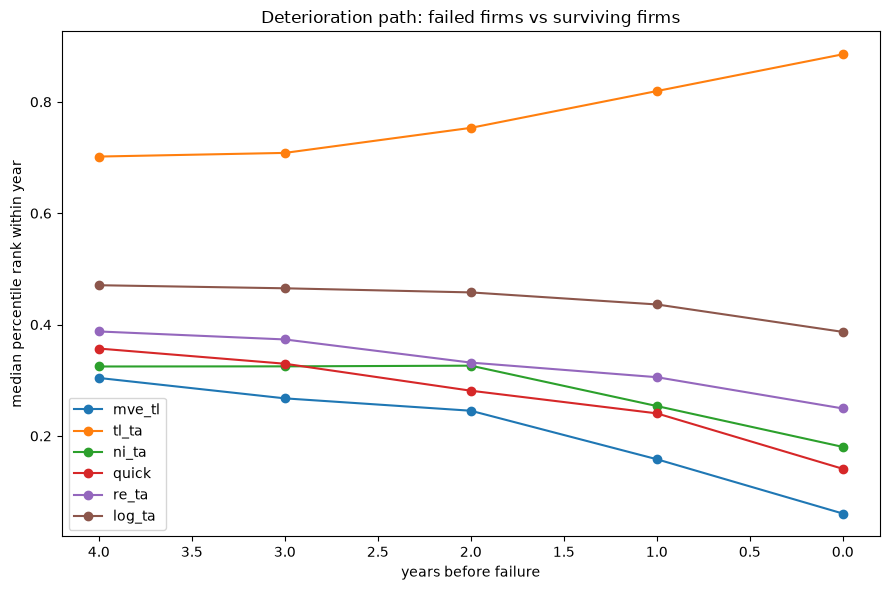

In [22]:
fig, ax = plt.subplots(figsize = (9, 6))
for c in FEATURES:
    ax.plot(path.index, path[c + "_r"], marker = "o", label = c)
ax.invert_xaxis()  
ax.set_ylabel("median percentile rank within year")
ax.set_xlabel("years before failure")
ax.set_title("Deterioration path: failed firms vs surviving firms")
ax.legend() 
plt.tight_layout()

Without the `long_hist` filter, the firms observed at t-4 are a different set from those at t-0, so any trends could be sample composition. Therefore, this is restricted to firms present across the whole window.

By ranking firms, within the years, the macro cycles are stripped.